First Approach: calculate regression coefficient and bias

In [64]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

df=pd.read_csv('Salary_Data.csv',sep=',')
print(df.head(10))

   YearsExperience   Salary
0              1.1  39343.0
1              1.3  46205.0
2              1.5  37731.0
3              2.0  43525.0
4              2.2  39891.0
5              2.9  56642.0
6              3.0  60150.0
7              3.2  54445.0
8              3.2  64445.0
9              3.7  57189.0


In [65]:
x_train=df["YearsExperience"]
y_train=df["Salary"]
print(x_train.head(10))
# print(y_train)

0    1.1
1    1.3
2    1.5
3    2.0
4    2.2
5    2.9
6    3.0
7    3.2
8    3.2
9    3.7
Name: YearsExperience, dtype: float64


Text(0, 0.5, 'Salary')

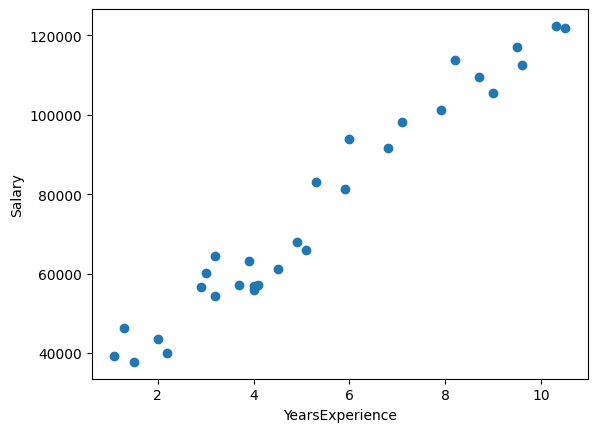

In [66]:
plt.scatter(x_train,y_train)
plt.xlabel("YearsExperience")
plt.ylabel("Salary")

linear regression:
f(x)=wx+b

w=slope

b=bias or intercept

In [67]:
#convert x_train and y_train into array 
x_train=np.array(x_train)
y_train=np.array(y_train)
print(x_train)
print(y_train)


[ 1.1  1.3  1.5  2.   2.2  2.9  3.   3.2  3.2  3.7  3.9  4.   4.   4.1
  4.5  4.9  5.1  5.3  5.9  6.   6.8  7.1  7.9  8.2  8.7  9.   9.5  9.6
 10.3 10.5]
[ 39343.  46205.  37731.  43525.  39891.  56642.  60150.  54445.  64445.
  57189.  63218.  55794.  56957.  57081.  61111.  67938.  66029.  83088.
  81363.  93940.  91738.  98273. 101302. 113812. 109431. 105582. 116969.
 112635. 122391. 121872.]


First Approach: calculate regression coefficient and bias

regression cofficient formula:

w= {n*sum(x*y) - sum(x)*sum(y)}/{n*sum(x**2) - (sum(x)**2)}

intercept formula:

b=(y-mean) - (w* (x-mean))

In [68]:
#sum and mean of all elements in x_train and y train

x_sum=x_train.sum()
y_sum=y_train.sum()
x_mean=x_sum/len(x_train)
y_mean=y_sum/len(y_train)
n=len(y_train)


print(x_sum)
print(y_sum)
print(x_mean)
print(y_mean)
print(n)

159.4
2280090.0
5.3133333333333335
76003.0
30


In [69]:
#sum of sqaures of all elements in x_train 
sum_x2=0
for i in x_train:
    sum_x2+=i**2
print(sum_x2)

1080.5


In [70]:
xy_sum = 0
for i, j in zip(x_train, y_train):
    xy_sum += i * j

print(xy_sum)

14321961.0


In [71]:
w= (((n*xy_sum)-(x_sum*y_sum)) / ((n*sum_x2)-(x_sum**2)))
b= y_mean - (w*x_mean)
print(w)    
print(b)

9449.962321455077
25792.20019866869


In [72]:
def predict(x):
    return w*x + b


print(predict(5))

73042.01180594409


In [73]:
def linear_regression(x_train,y_train,x):
    x_sum=x_train.sum()
    y_sum=y_train.sum()
    x_mean=x_sum/len(x_train)
    y_mean=y_sum/len(y_train)
    n=len(y_train)

    sum_x2=0
    for i in x_train:
        sum_x2+=i**2
    xy_sum = 0
    for i, j in zip(x_train, y_train):
        xy_sum += i * j
    w= (((n*xy_sum)-(x_sum*y_sum)) / ((n*sum_x2)-(x_sum**2)))
    b= y_mean - (w*x_mean)

    print(float(w*x + b)) 

y_pred=linear_regression(x_train,y_train,5)
# print(y_pred)


73042.01180594409


1532116.1942386082


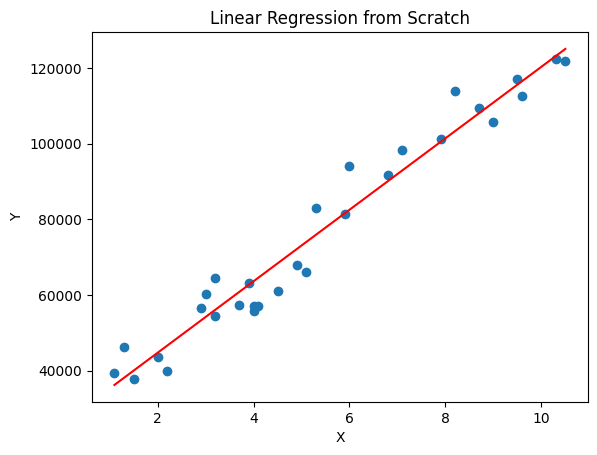

In [74]:
import numpy as np
import matplotlib.pyplot as plt

def linear_regression(x_train, y_train):
    x_sum = x_train.sum()
    y_sum = y_train.sum()
    x_mean = x_sum / len(x_train)
    y_mean = y_sum / len(y_train)
    n = len(y_train)

    sum_x2 = 0
    for i in x_train:
        sum_x2 += i**2

    xy_sum = 0
    for i, j in zip(x_train, y_train):
        xy_sum += i * j

    w = ((n * xy_sum) - (x_sum * y_sum)) / ((n * sum_x2) - (x_sum**2))
    b = y_mean - (w * x_mean)
    print(float(w*x + b)) 
    return w, b


# Sample Data
x_train=df["YearsExperience"]
y_train=df["Salary"]


# Train model
w, b = linear_regression(x_train, y_train)

# Predictions for line
y_pred = w * x_train + b

# 🔹 Plot
plt.scatter(x_train, y_train)   # actual points
plt.plot(x_train, y_pred,color="red")       # regression line

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Linear Regression from Scratch")

plt.show()

In [ ]:
from linear_regression_normal_form import linear_regression
linear_regression(x_train,y_train,5)

73042.01180594409


functions required:

1. cost fucniton - rmse

2. gradient function

3. gradient descent function 